# Kumaraswamy Distribution

`Kumaraswamy(a, b)` is a continuous distribution on [0, 1] for proportions and probabilities. Both shape parameters must be positive: larger `a` shifts values toward 1, larger `b` shifts them toward 0.

In [1]:
from symbulate import *

## Draw a value from a Kumaraswamy distribution

In [2]:
Kumaraswamy(a=2, b=5).draw()

0.4076401204802604

## Theoretical mean, variance, and standard deviation

In [3]:
Kumaraswamy(a=2, b=5).mean(), Kumaraswamy(a=2, b=5).var(), Kumaraswamy(a=2, b=5).sd()

(np.float64(0.3694083694083694),
 np.float64(0.03020412327771635),
 np.float64(0.17379333496344546))

## Assign and simulate a random variable

In [4]:
K1 = RV(Kumaraswamy(a=2, b=5))
K1.sim(10000)

0,0.4138106560213928
1,0.5605321409301262
2,0.11729234040265153
3,0.44698850562022613
4,0.22575004423301856
5,0.31434408152160626
6,0.0956758578995316
7,0.22714908509666967
8,0.3573539128470725
...,...
9999,0.3892695412482927


## Plot the pdf

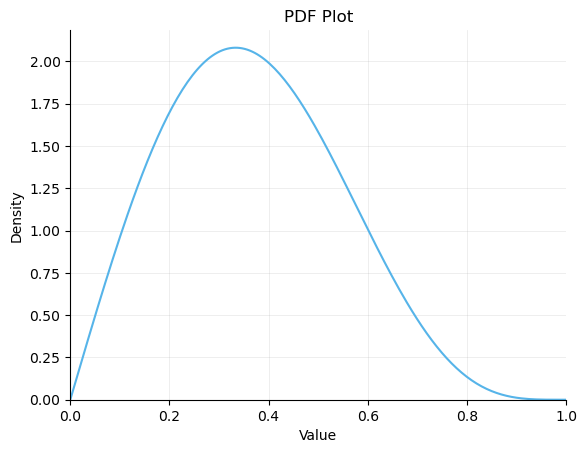

In [5]:
Kumaraswamy(a=2, b=5).plot()

## Plot the CDF

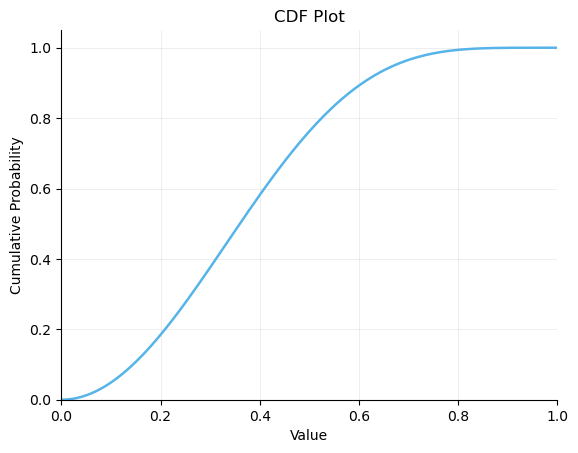

In [6]:
Kumaraswamy(a=2, b=5).plot(cdf=True)

## Special case: a = 1 is the Beta(1, b) distribution

With `a = 1` the cdf is `1 - (1 - x) ** b`, which is exactly the cdf of `Beta(1, b)`. The two curves land on top of each other.

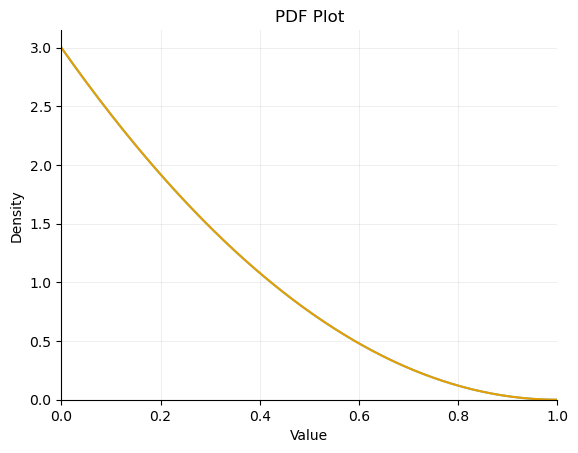

In [7]:
Kumaraswamy(a=1, b=3).plot()
Beta(a=1, b=3).plot()

## Special case: b = 1 is the Beta(a, 1) distribution

With `b = 1` the cdf is `x ** a`, which is exactly the cdf of `Beta(a, 1)`.

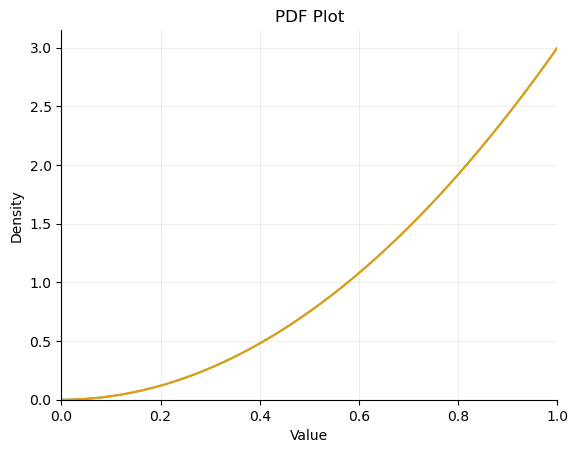

In [8]:
Kumaraswamy(a=3, b=1).plot()
Beta(a=3, b=1).plot()

## Shape parameters change the curve

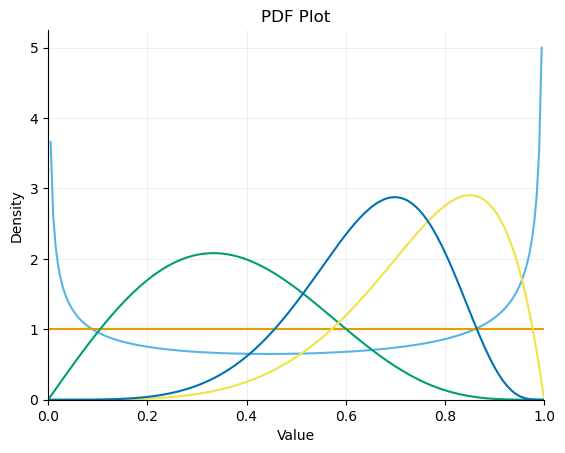

In [9]:
for a, b in [(0.5, 0.5), (1, 1), (2, 5), (5, 2), (5, 5)]:
    Kumaraswamy(a=a, b=b).plot()

## Relationships

Each construction below is simulated, drawn as a normalized histogram, and overlaid with the theoretical `Kumaraswamy` density; the last section compares the Kumaraswamy against the `Beta` directly. All of them require `a > 0` and `b > 0`.

### Building a Kumaraswamy from a Uniform

If `U` is `Uniform(0, 1)`, then

$$X = \left(1 - (1 - U)^{1/b}\right)^{1/a}$$

has a `Kumaraswamy(a, b)` distribution. This is the inverse-cdf construction: the formula is the Kumaraswamy quantile function, so it works for **any** `a > 0` and `b > 0`. Below, `a = 2` and `b = 5`.

Currently Showing: Histogram (Default)
Alternative Plots: Rug Plot (type = "rug"), Density Plot (type = "density"), Box Plot (type = "box"), Violin Plot (type = "violin"), ECDF Plot (type = "ecdf")


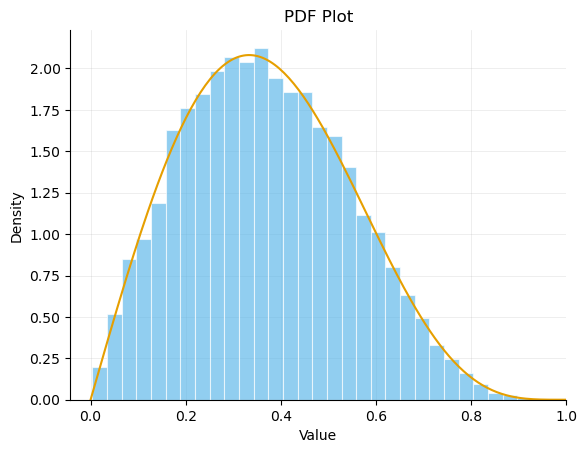

In [10]:
a, b = 2, 5

U = RV(Uniform(0, 1))
X = (1 - (1 - U) ** (1 / b)) ** (1 / a)

X.sim(10000).plot(type="hist")
Kumaraswamy(a=a, b=b).plot()

### Special case a = 1: a transformed Uniform, and a Beta(1, b)

Setting `a = 1` collapses the construction to $X = 1 - (1 - U)^{1/b}$, and `Kumaraswamy(1, b)` **is** `Beta(1, b)` exactly. Simulating from `Beta(1, b)` and overlaying the Kumaraswamy density shows the same distribution twice. Here `b = 3`; the equality holds only because `a = 1`.

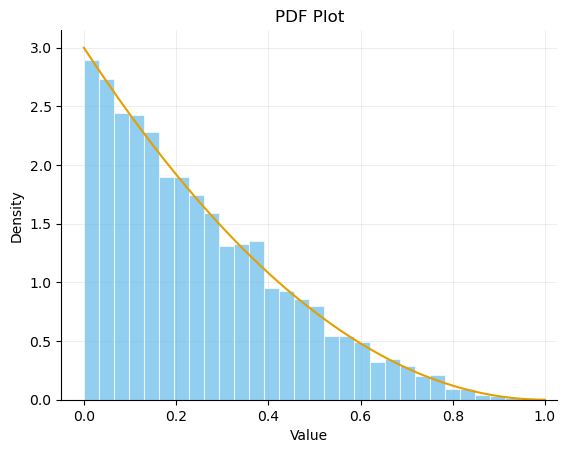

In [11]:
b = 3

RV(Beta(a=1, b=b)).sim(10000).plot(type="hist")
Kumaraswamy(a=1, b=b).plot()

### Special case b = 1: a power of a Uniform, and a Beta(a, 1)

Setting `b = 1` collapses the construction to $X = U^{1/a}$, and `Kumaraswamy(a, 1)` **is** `Beta(a, 1)` exactly — the power-function distribution. Here `a = 4`; the equality holds only because `b = 1`.

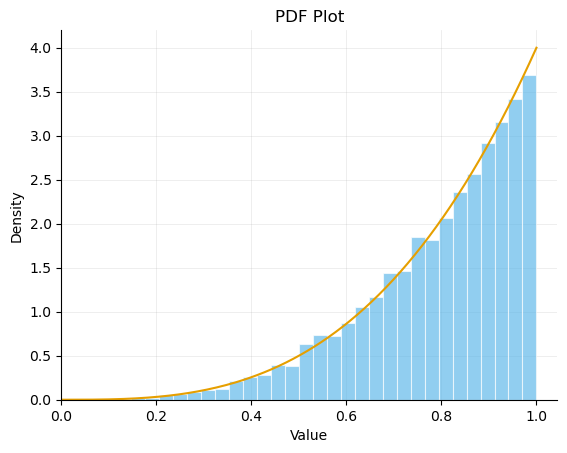

In [12]:
a = 4

U = RV(Uniform(0, 1))
(U ** (1 / a)).sim(10000).plot(type="hist")
Kumaraswamy(a=a, b=1).plot()

### The general link to the Beta: a root of a Beta(1, b)

For general `a` and `b` the Kumaraswamy is not a Beta, but the two families are still connected: if `Y` is `Beta(1, b)`, then $Y^{1/a}$ is `Kumaraswamy(a, b)`. (Equivalently, if `X` is `Kumaraswamy(a, b)`, then $X^a$ is `Beta(1, b)`.) Note the first Beta parameter must be **1** — no other Beta works. Below, `a = 3` and `b = 2`.

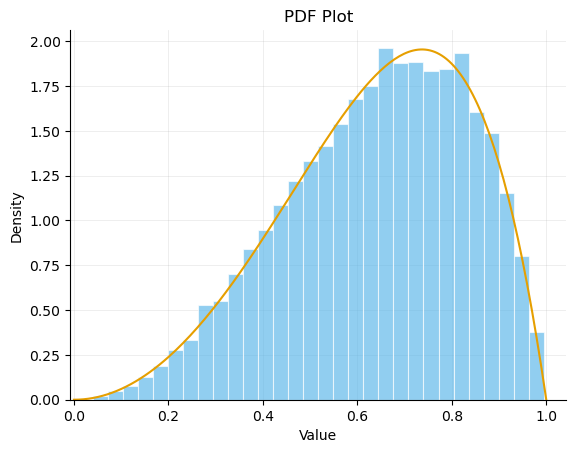

In [13]:
a, b = 3, 2

Y = RV(Beta(a=1, b=b))
(Y ** (1 / a)).sim(10000).plot(type="hist")
Kumaraswamy(a=a, b=b).plot()

### Kumaraswamy compared to Beta

Outside the two special cases, `Kumaraswamy(a, b)` and `Beta(a, b)` with the *same* parameter values are different distributions — same support and a similar shape, but not the same curve.

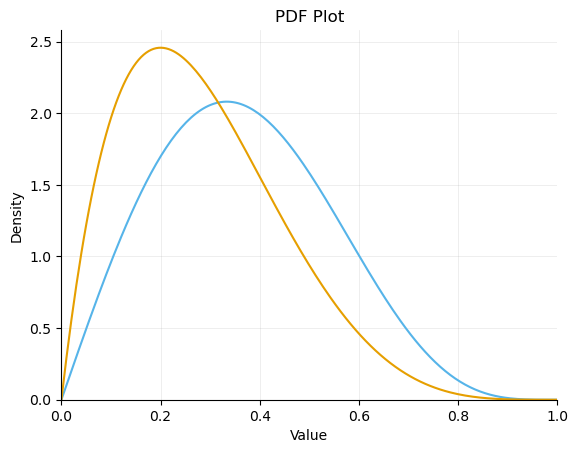

In [14]:
Kumaraswamy(a=2, b=5).plot()
Beta(a=2, b=5).plot()

In [15]:
Kumaraswamy(a=2, b=5).mean(), Beta(a=2, b=5).mean()

(np.float64(0.3694083694083694), np.float64(0.2857142857142857))

Matching the Beta's parameters to the Kumaraswamy's mean and variance brings the two much closer, but they still differ in the tails — the families overlap only at `a = 1` and `b = 1`.

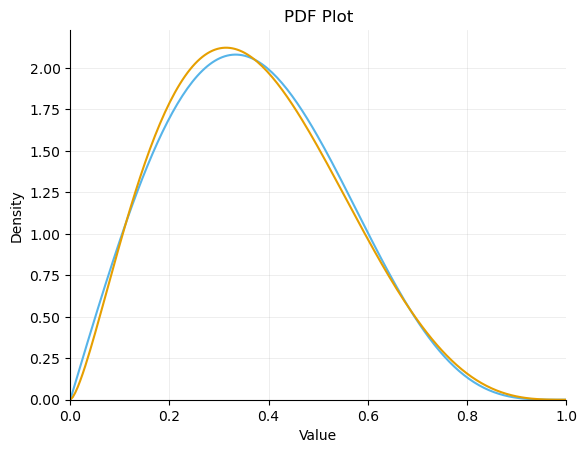

In [16]:
K = Kumaraswamy(a=2, b=5)
m, v = float(K.mean()), float(K.var())
c = m * (1 - m) / v - 1  # matches a Beta's mean and variance to K's

K.plot()
Beta(a=m * c, b=(1 - m) * c).plot()